# 基于结构化感知器（Structured Perceptron）的中文分词教学案例

**课程关联**：与此前"基于线性链条件随机场（CRF）的中文分词"教学案例姊妹篇，建议先学习 CRF 版本再学习本案例，二者共享相同的任务建模方式（BMES 序列标注）与特征模板设计，便于横向对比两种判别式序列模型的异同。

**教学定位**：本 Notebook 同样**不依赖任何现成工具包**，完全使用 NumPy 从零实现结构化感知器（Structured Perceptron）及其改进版本——**平均感知器（Averaged Perceptron）**，并配套独立的数据文件（而非在代码中硬编码语料），更贴近真实项目的工作方式。

## 学习目标

1. 理解结构化感知器与普通（多类）感知器的区别：如何在指数级大小的标签序列空间中用维特比算法求解 $\arg\max$。
2. 掌握感知器的在线学习更新规则："预测错了就调整权重，预测对了就不调整"，并与 CRF 的概率梯度更新对比。
3. 理解平均感知器的动机与实现方式，了解其与最大间隔（Max-Margin）方法的联系。
4. 能够从外部数据文件加载语料、训练模型、评估效果，并对错误案例进行分析。
5. 通过对比感知器与 CRF 两种方法，总结判别式序列模型的共性与差异。

> **数据文件说明**：本案例配套三个数据文件，请与本 Notebook 放在**同一目录**下（或按需修改下方 `DATA_DIR` 变量）：
> - `train.txt`：训练语料，54 个已分词句子，词语间以空格分隔；
> - `test.txt`：测试语料，16 个已分词句子，格式同上；
> - `demo.txt`：8 个未分词的原始句子，用于演示模型预测效果；
> - `README.md`：数据格式说明文档。


## 一、任务回顾：中文分词 = 字符级 BMES 序列标注

与 CRF 教学案例一致，我们把分词任务转化为对每个字符预测 BMES 标签的序列标注问题：

| 标签 | 含义 |
| --- | --- |
| B | 词语的第一个字 |
| M | 词语的中间字 |
| E | 词语的最后一个字 |
| S | 单字成词 |

例如"自然语言处理"对应标签序列 `B E B E B E`，还原后即为"自然/语言/处理"。


## 二、结构化感知器原理

### 1. 从普通感知器到结构化感知器

普通（二分类/多分类）感知器的预测规则是 $\hat{y} = \arg\max_y w \cdot f(x, y)$，标签空间很小（如 BMES 只有 4 个标签），可以直接枚举比较。

但**序列标注**问题的标签空间是指数级的：长度为 $n$ 的句子有 $4^n$ 种可能的标签序列，无法枚举。**结构化感知器（Collins, 2002）**的核心思想是：只要预测函数 $\arg\max$ 可以用动态规划高效求解，感知器的学习框架就可以直接推广到结构化输出问题。

对于线性链结构，我们使用与 CRF 教学案例**完全相同的特征分解方式**（状态特征 + 转移特征）：

$$
\text{score}(x, y) = \sum_{i=1}^n w \cdot f_{\text{state}}(y_i, x, i) + \sum_{i=1}^{n-1} T[y_{i-1}, y_i]
$$

预测时同样使用**维特比算法**求解 $\hat{y} = \arg\max_y \text{score}(x,y)$。

> **与 CRF 的关键区别**：CRF 的 $\text{score}$ 经过 $\exp(\cdot)/Z(x)$ 归一化为概率分布，训练时最大化对数似然，梯度基于前向-后向算法计算的**期望特征计数**；感知器**不做概率归一化**，直接对原始得分做 $\arg\max$，训练时只需要维特比算法，**不需要计算配分函数**，因此训练更快、实现更简单，但代价是模型不能输出校准的概率值。

### 2. 感知器更新规则

对每个训练样本 $(x, y^*)$（$y^*$ 为标准答案）：

1. 用当前权重通过维特比解码得到预测 $\hat{y} = \arg\max_y \text{score}(x, y)$；
2. 如果 $\hat{y} = y^*$（预测正确），**不更新**权重；
3. 如果 $\hat{y} \neq y^*$（预测错误），按如下规则更新：

$$
w \leftarrow w + f(x, y^*) - f(x, \hat{y})
$$

直观理解：**提升标准答案路径的得分，压低错误预测路径的得分**。这是感知器算法"错误驱动学习（Error-driven Learning）"的直接体现——与教材第 3 章依存句法分析中介绍的感知器算法（用于学习边评分模型权重）思想完全一致，这里是其在序列标注任务上的应用。

### 3. 平均感知器（Averaged Perceptron）

朴素感知器在训练后期权重可能出现震荡（尤其数据非完全线性可分或训练轮数不足时），直接使用最后一轮的权重容易对近期样本过拟合。**平均感知器**的做法是：记录训练过程中**每一次参数更新后的权重快照**，最终取所有快照的平均值作为预测时使用的权重：

$$
\bar{w} = \frac{1}{T}\sum_{t=1}^{T} w^{(t)}
$$

这一技巧被证明能够有效降低方差、提升测试集泛化效果（Freund & Schapire, 1999；Collins, 2002），且相比原始感知器**不增加额外的超参数**，是工业界序列标注系统中常用的"免费"改进手段。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

np.random.seed(42)
%matplotlib inline


## 三、从数据文件加载语料

与 CRF 案例不同，本次语料以**独立文本文件**的形式提供，更贴近真实项目的数据组织方式。请确保 `train.txt`、`test.txt`、`demo.txt` 与本 Notebook 位于同一目录（如目录结构不同，请修改下面的 `DATA_DIR`）。

`train.txt` / `test.txt` 格式：每行一个已分词句子，词语间以**单个空格**分隔，例如：

```
自然 语言 处理 是 人工智能 的 一个 重要 方向
我们 正在 学习 中文 分词 方法
```

`demo.txt` 格式：每行一个**未分词**的原始句子，用于最终效果演示。


In [2]:
DATA_DIR = "."  # 如数据文件位于子目录，例如 "./data"，请改为对应路径

def load_segmented_file(path):
    """读取"词语以空格分隔"的分词语料文件，返回 [[word1, word2, ...], ...]"""
    sents = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                sents.append(line.split(" "))
    return sents

def load_raw_file(path):
    """读取未分词的原始句子文件，返回句子字符串列表"""
    with open(path, encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]

train_words = load_segmented_file(os.path.join(DATA_DIR, "train.txt"))
test_words = load_segmented_file(os.path.join(DATA_DIR, "test.txt"))
demo_sentences = load_raw_file(os.path.join(DATA_DIR, "demo.txt"))

print(f"训练集句子数：{len(train_words)}")
print(f"测试集句子数：{len(test_words)}")
print(f"演示句子数：{len(demo_sentences)}")
print("\n训练集样例：", " / ".join(train_words[0]))


训练集句子数：54
测试集句子数：16
演示句子数：8

训练集样例： 这次 / 实验 / 使用 / 了 / 一 / 个 / 小型 / 的 / 教学 / 语料 / 库


In [3]:
def word_to_bmes(word):
    n = len(word)
    if n == 1:
        return ["S"]
    return ["B"] + ["M"] * (n - 2) + ["E"]

def sentence_to_chars_tags(words):
    chars, tags = [], []
    for w in words:
        chars.extend(list(w))
        tags.extend(word_to_bmes(w))
    return chars, tags

train_data = [sentence_to_chars_tags(ws) for ws in train_words]
test_data = [sentence_to_chars_tags(ws) for ws in test_words]

chars0, tags0 = train_data[0]
display(pd.DataFrame([chars0, tags0], index=["字符", "BMES标签"]))


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
字符,这,次,实,验,使,用,了,一,个,小,型,的,教,学,语,料,库
BMES标签,B,E,B,E,B,E,S,S,S,B,E,S,B,E,B,E,S


## 四、特征模板（与 CRF 案例保持一致）

沿用 CRF 教学案例中的经典字符特征模板组合，便于两个模型在**完全相同的特征空间**下公平对比：

| 模板 | 定义 |
| --- | --- |
| U00 | 前一个字 $c_{-1}$ |
| U01 | 当前字 $c_{0}$ |
| U02 | 后一个字 $c_{1}$ |
| U03 | $c_{-1}c_{0}$ 二元组合 |
| U04 | $c_{0}c_{1}$ 二元组合 |


In [4]:
LABELS = ["B", "M", "E", "S"]
L2I = {l: i for i, l in enumerate(LABELS)}
NUM_LABELS = len(LABELS)

def char_at(chars, i):
    if i < 0 or i >= len(chars):
        return "<PAD>"
    return chars[i]

def extract_templates(chars, i):
    c_1, c0, c1 = char_at(chars, i - 1), char_at(chars, i), char_at(chars, i + 1)
    return [f"U00:{c_1}", f"U01:{c0}", f"U02:{c1}", f"U03:{c_1}{c0}", f"U04:{c0}{c1}"]

feat2id = {}
def get_feat_id(f, allow_new):
    if f in feat2id:
        return feat2id[f]
    if allow_new:
        fid = len(feat2id)
        feat2id[f] = fid
        return fid
    return -1  # 预测阶段遇到未登录特征，直接忽略（权重视为0）

def sentence_feature_ids(chars, allow_new):
    return [[get_feat_id(f, allow_new) for f in extract_templates(chars, i)] for i in range(len(chars))]

train_feat_ids = [sentence_feature_ids(chars, allow_new=True) for chars, _ in train_data]
test_feat_ids = [sentence_feature_ids(chars, allow_new=False) for chars, _ in test_data]

NUM_FEATS = len(feat2id)
print(f"从训练语料中共登记 {NUM_FEATS} 个不同的特征模板实例")


从训练语料中共登记 2240 个不同的特征模板实例


## 五、结构化感知器的 NumPy 实现

`StructuredPerceptron` 类包含：

- `node_scores`：与 CRF 案例相同，计算每个位置对每个标签的状态得分（这里不取 exp，是**原始线性得分**）；
- `viterbi`：动态规划求解得分最高的标签序列（不涉及 $\log Z$，比 CRF 的维特比更简单）；
- `update_one`：对单个句子执行一次"预测-比较-更新"，这是感知器算法的核心；
- `fit`：多轮遍历训练集，每轮统计"错误率"（mistake rate）观察收敛过程；
- `get_averaged`：返回平均化后的权重，用于与"最后一轮朴素权重"对比。


In [5]:
class StructuredPerceptron:
    def __init__(self, num_feats, num_labels):
        self.num_feats = num_feats
        self.num_labels = num_labels
        self.W = np.zeros((num_feats, num_labels))   # 状态特征权重（当前/最新）
        self.T = np.zeros((num_labels, num_labels))  # 转移权重 T[y_prev, y_cur]（当前/最新）
        self.avgW = np.zeros_like(self.W)             # 累加器，用于最后求平均
        self.avgT = np.zeros_like(self.T)
        self.updates = 0                               # 累加次数（每处理一个句子加1）

    def node_scores(self, feat_ids, W=None):
        W = self.W if W is None else W
        n = len(feat_ids)
        scores = np.zeros((n, self.num_labels))
        for i in range(n):
            ids = [f for f in feat_ids[i] if f >= 0]
            if ids:
                scores[i] = W[ids].sum(axis=0)
        return scores

    def viterbi(self, feat_ids, W=None, T=None):
        """维特比算法求最优标签序列（返回标签下标列表），W/T 可指定使用平均权重"""
        W = self.W if W is None else W
        T = self.T if T is None else T
        node_sc = self.node_scores(feat_ids, W)
        n = node_sc.shape[0]
        L = self.num_labels
        dp = np.zeros((n, L))
        bp = np.zeros((n, L), dtype=int)
        dp[0] = node_sc[0]
        for i in range(1, n):
            scores = dp[i - 1][:, None] + T
            bp[i] = np.argmax(scores, axis=0)
            dp[i] = node_sc[i] + np.max(scores, axis=0)
        y = [int(np.argmax(dp[-1]))]
        for i in range(n - 1, 0, -1):
            y.append(int(bp[i][y[-1]]))
        y.reverse()
        return y

    def update_one(self, feat_ids, gold_ids):
        """对单个句子执行一次感知器更新，返回是否发生了预测错误"""
        pred_ids = self.viterbi(feat_ids)
        n = len(gold_ids)
        mistake = (pred_ids != gold_ids)
        if mistake:
            # 状态特征：标准答案位置 +1，错误预测位置 -1
            for i in range(n):
                for f in feat_ids[i]:
                    if f >= 0:
                        self.W[f, gold_ids[i]] += 1.0
                        self.W[f, pred_ids[i]] -= 1.0
            # 转移特征：标准答案的相邻标签对 +1，错误预测的相邻标签对 -1
            for i in range(n - 1):
                self.T[gold_ids[i], gold_ids[i + 1]] += 1.0
                self.T[pred_ids[i], pred_ids[i + 1]] -= 1.0
        # 无论是否更新，都累加当前权重快照，用于事后求平均
        self.updates += 1
        self.avgW += self.W
        self.avgT += self.T
        return mistake

    def get_averaged(self):
        return self.avgW / self.updates, self.avgT / self.updates

    def fit(self, feat_ids_list, tags_list, epochs=20, shuffle=True, verbose=True):
        n_sent = len(feat_ids_list)
        order = list(range(n_sent))
        mistake_rates = []
        for ep in range(epochs):
            if shuffle:
                np.random.shuffle(order)
            mistakes = 0
            for idx in order:
                gold_ids = [L2I[t] for t in tags_list[idx]]
                if self.update_one(feat_ids_list[idx], gold_ids):
                    mistakes += 1
            rate = mistakes / n_sent
            mistake_rates.append(rate)
            if verbose and (ep % 2 == 0 or ep == epochs - 1):
                print(f"epoch {ep:2d}  训练集错误率 = {rate:.3f}")
        return mistake_rates


## 六、模型训练

训练过程中我们记录**每一轮训练集上的"句子级错误率"**（即维特比预测与标准答案不完全一致的句子占比），这是感知器训练最直观的监控指标——理论上，如果训练数据线性可分，感知器的错误次数存在与数据"间隔（margin）"相关的**有限误差界（Novikoff, 1962）**，即错误率最终会降到 0（对训练集），可以在下方曲线中直接观察到这一收敛现象。


epoch  0  训练集错误率 = 0.907
epoch  2  训练集错误率 = 0.130
epoch  4  训练集错误率 = 0.019
epoch  6  训练集错误率 = 0.037
epoch  8  训练集错误率 = 0.000
epoch 10  训练集错误率 = 0.000
epoch 12  训练集错误率 = 0.000
epoch 14  训练集错误率 = 0.000
epoch 16  训练集错误率 = 0.000
epoch 18  训练集错误率 = 0.000
epoch 19  训练集错误率 = 0.000


D:\AnacondaFiles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\AnacondaFiles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\AnacondaFiles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\AnacondaFiles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21477 (\N{CJK UNIFIED IDEOGRAPH-53E5}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\AnacondaFiles\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\AnacondaFiles\Lib\site-pack

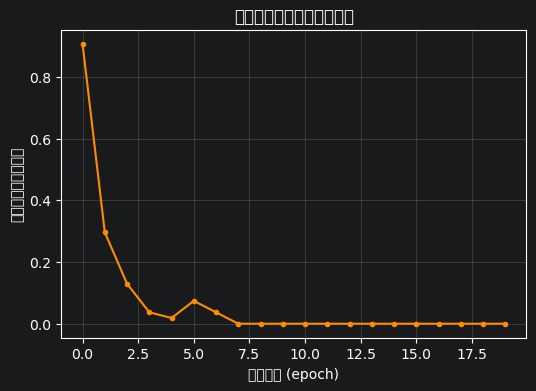

In [6]:
perc = StructuredPerceptron(NUM_FEATS, NUM_LABELS)
train_tags = [tags for _, tags in train_data]

mistake_rates = perc.fit(train_feat_ids, train_tags, epochs=20)

plt.figure(figsize=(6, 4))
plt.plot(mistake_rates, marker="o", markersize=3, color="darkorange")
plt.xlabel("训练轮次 (epoch)")
plt.ylabel("训练集句子级错误率")
plt.title("结构化感知器训练收敛曲线")
plt.grid(alpha=0.3)
plt.show()


## 七、模型评估：朴素感知器 vs 平均感知器

与 CRF 案例相同，采用基于词语片段（span）的 Precision / Recall / F1 评价分词效果。这里我们**同时评估两组权重**：

- 训练结束时的"最后一轮朴素权重"（`perc.W`, `perc.T`）；
- 对训练全程权重取平均得到的"平均权重"（`avgW`, `avgT`）。

> **教学提示**：由于本案例语料规模小、特征模板表达能力较强，感知器很容易在训练集上做到完全线性可分（错误率降为 0），此时朴素权重与平均权重的差异会比较有限，甚至平均权重可能因为"平均了训练早期尚未收敛的权重快照"而略逊于收敛后的朴素权重。这恰好说明了平均感知器的适用场景：**当训练轮数有限、数据存在噪声或不完全线性可分时，平均化带来的方差降低效果最明显**；在小型、干净、可分的教学语料上二者差距不大是正常现象，请结合思考题第 2 题在更大/更嘈杂的语料上重新验证。


In [7]:
def bmes_to_spans(tags):
    spans, start = [], None
    for i, tg in enumerate(tags):
        if tg in ("B", "S"):
            start = i
        if tg in ("E", "S"):
            spans.append((start, i))
    return spans

def bmes_to_words(chars, tags):
    words, cur = [], ""
    for ch, tg in zip(chars, tags):
        if tg == "S":
            if cur:
                words.append(cur); cur = ""
            words.append(ch)
        elif tg == "B":
            if cur:
                words.append(cur)
            cur = ch
        elif tg == "M":
            cur += ch
        elif tg == "E":
            cur += ch
            words.append(cur); cur = ""
    if cur:
        words.append(cur)
    return words

def evaluate(model, W, T, data, feat_ids_list):
    correct = pred_total = gold_total = 0
    for (chars, gold_tags), feat_ids in zip(data, feat_ids_list):
        pred_ids = model.viterbi(feat_ids, W, T)
        pred_tags = [LABELS[i] for i in pred_ids]
        gold_spans = set(bmes_to_spans(gold_tags))
        pred_spans = set(bmes_to_spans(pred_tags))
        correct += len(gold_spans & pred_spans)
        pred_total += len(pred_spans)
        gold_total += len(gold_spans)
    P = correct / pred_total if pred_total else 0.0
    R = correct / gold_total if gold_total else 0.0
    F1 = 2 * P * R / (P + R) if (P + R) else 0.0
    return P, R, F1

avgW, avgT = perc.get_averaged()

P1, R1, F1_1 = evaluate(perc, perc.W, perc.T, test_data, test_feat_ids)
P2, R2, F1_2 = evaluate(perc, avgW, avgT, test_data, test_feat_ids)

result_df = pd.DataFrame({
    "模型": ["朴素感知器（最后一轮权重）", "平均感知器（全程权重平均）"],
    "Precision": [P1, P2],
    "Recall": [R1, R2],
    "F1": [F1_1, F1_2],
})
display(result_df.round(3))


,模型,Precision,Recall,F1
0,朴素感知器（最后一轮权重）,0.889,0.907,0.898
1,平均感知器（全程权重平均）,0.876,0.893,0.884


## 八、在新句子上测试

使用 `demo.txt` 中未分词的原始句子测试模型效果，并直接展示逐句分词结果与错误案例分析。


In [8]:
def segment(sentence, W, T):
    chars = list(sentence)
    feat_ids = sentence_feature_ids(chars, allow_new=False)
    pred_ids = perc.viterbi(feat_ids, W, T)
    tags = [LABELS[i] for i in pred_ids]
    return bmes_to_words(chars, tags)

rows = []
for s in demo_sentences:
    rows.append({
        "原句": s,
        "朴素感知器分词": "/".join(segment(s, perc.W, perc.T)),
        "平均感知器分词": "/".join(segment(s, avgW, avgT)),
    })
display(pd.DataFrame(rows))


,原句,朴素感知器分词,平均感知器分词
0,自然语言处理需要用到条件随机场和感知器模型,自然/语言/处理/需要/用到/条件/随机场/和/感知器/模型,自然/语言/处理/需要/用到/条件/随机场/和/感知器/模型
1,同学们正在图书馆认真准备明天的考试,同学/们/正在/图书馆/认真/准/备明/天/的/考试,同学/们/正在/图书/馆/认真/准备/明天/的/考试
2,结构化感知器需要用维特比算法求解最优路径,结构化/感知器/需要/用/维特比/算法/求解/最/优/路径,结构化/感知器/需要/用维/特比/算法/求解/最/优/路径
3,北京的科技公司正在招聘自然语言处理工程师,北京/的/科技/公司/正在/招聘/自然/语言/处理/工程师,北京/的/科技/公司/正在/招聘/自然/语言/处理/工程/师
4,平均感知器有效缓解了模型的过拟合问题,平均/感知器/有效/缓解/了/模型/的/过/拟合/问题,平均/感知器/有效/缓解/了/模型/的/过/拟合/问题
5,深度学习算法近年来发展非常迅速,深度/学习/算法/近年来/发展/非常/迅速,深度/学习/算法/近年来/发展/非常/迅速
6,我们希望模型能够正确识别没有见过的新词语,我们/希望/模型/能够/正确/识别/没/有见/过/的/新/词语,我们/希望/模型/能够/正确/识别/没/有见/过/的/新词/语
7,这门课程介绍了从规则方法到统计方法的演进过程,这/门/课程/介绍/了/从/规则/方法/到/统计/方法/的/演进/过程,这/门/课程/介绍/了/从/规则/方法/到/统计/方法/的/演进/过程


**错误案例分析提示**：请观察上表中是否存在类似"结构化感知器"被误切为"结构化/感知器"内部某个词被进一步错误拆分（例如"维特比"被拆开）的情况。这类错误通常源于：

1. 该词语的字符组合在训练语料中出现次数过少，特征权重未被充分学习；
2. 未登录词（OOV, Out-of-Vocabulary）问题——训练语料规模有限是根本原因。

这也是为什么工业级分词系统需要**大规模标注语料 + 词典特征 + 神经网络上下文表示**等手段来缓解数据稀疏问题。


## 九、感知器 vs 条件随机场：横向对比

结合本案例与此前的 CRF 教学案例，从多个维度对比两种线性判别式序列模型：

| 维度 | 结构化感知器 | 线性链 CRF |
| --- | --- | --- |
| 输出 | 原始得分（无概率意义） | 归一化条件概率 $P(y\mid x)$ |
| 训练目标 | 最小化"预测错误次数"（隐式的 0-1 损失近似） | 最大化条件对数似然 |
| 是否需要配分函数 $Z(x)$ | 不需要 | 需要（前向-后向算法计算） |
| 每步计算复杂度 | 只需一次维特比解码 | 需要维特比（预测时）+ 前向-后向（训练时） |
| 训练速度 | 更快（无需计算 $\log Z$ 及其梯度） | 相对较慢 |
| 是否需要正则化防止权重发散 | 通常配合平均化技巧即可，也可加 L2 | 通常显式加入 L2 正则 |
| 理论保证 | 数据线性可分时有误差界（Novikoff 定理） | 最大似然估计的一致性 |
| 实践效果 | 与 CRF 接近，实现更简单 | 通常略优或相当，可输出置信度 |

**核心结论**：感知器可以看作是 CRF 的一种"简化+近似"版本——用 $\arg\max$ 硬解码替代了 CRF 的期望（软性加权）计算，牺牲了概率解释性换来了更简单、更快速的训练过程。二者在特征模板完全相同的情况下，通常能达到相近的分词效果，这也是为什么感知器在 21 世纪前十年曾是工业界序列标注任务的主流选择之一（例如早期的品词标注器、命名实体识别器）。


## 十、总结与思考题

### 本课小结

1. 结构化感知器将感知器的"错误驱动学习"思想推广到序列标注任务，通过维特比解码实现结构化预测的 $\arg\max$；
2. 更新规则简洁直观：预测错误时，标准答案特征 +1，错误预测特征 -1；
3. 平均感知器通过对训练全程权重取平均，缓解朴素感知器的震荡与过拟合，是几乎零成本的实用改进；
4. 感知器与 CRF 共享相同的特征模板设计思路，但训练机制（硬解码 vs 概率归一化）不同，各有优劣。

### 课后思考题

1. **错误率曲线分析**：观察训练集错误率曲线，找到错误率首次降为 0 的轮次，并解释这是否意味着模型已经"学会"了中文分词，还是仅仅"记住"了训练语料（结合测试集 F1 讨论）。
2. **扩充数据文件**：自行在 `train.txt` 追加 20~30 个新句子（包含更多样的词语），重新训练并观察平均感知器相对朴素感知器的优势是否更明显，验证"数据噪声/不可分程度越高，平均化收益越大"的结论。
3. **实现最大间隔感知器（MIRA）**（拓展）：教材依存句法分析章节提到最大生成树依存句法分析器（MSTParser）在感知器基础上引入了最大间隔目标函数和 MIRA（Margin-Infused Relaxed Algorithm）算法，请查阅相关资料，思考 MIRA 相对普通感知器的改进点是什么。
4. **特征模板对比实验**：分别使用感知器和 CRF（可复用上一次课的 CRF 实现）在完全相同的 `train.txt` / `test.txt` 上训练，对比二者的训练耗时与测试集 F1，验证本节"横向对比表"中的结论。
5. **迁移到真实语料**：将本案例的数据加载接口（`load_segmented_file`）替换为读取 PKU/MSR 等真实分词语料库，讨论在大规模数据下感知器训练效率（尤其是特征稀疏存储与增量更新）需要做哪些工程优化。

